<a href="https://colab.research.google.com/github/navirath/ML-lab/blob/main/Copy_of_Logistic_Regression_Binary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import io

print("Please upload your file:")
uploaded = files.upload()

if not uploaded:
    print("No file was uploaded.")
else:
    for file_name, content_bytes in uploaded.items():
        print(f"\nProcessing uploaded file: '{file_name}'")
        try:
            # Decode the bytes content to a string, assuming UTF-8 encoding
            content_str = content_bytes.decode('utf-8')
            print(f"Content of '{file_name}':\n{content_str}")
        except Exception as e:
            print(f"An error occurred while reading or decoding '{file_name}': {e}")

Please upload your file:


Saving HR_comma_sep.csv to HR_comma_sep.csv

Processing uploaded file: 'HR_comma_sep.csv'
Content of 'HR_comma_sep.csv':
satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0.38,0.53,2,157,3,0,1,0,sales,low
0.8,0.86,5,262,6,0,1,0,sales,medium
0.11,0.88,7,272,4,0,1,0,sales,medium
0.72,0.87,5,223,5,0,1,0,sales,low
0.37,0.52,2,159,3,0,1,0,sales,low
0.41,0.5,2,153,3,0,1,0,sales,low
0.1,0.77,6,247,4,0,1,0,sales,low
0.92,0.85,5,259,5,0,1,0,sales,low
0.89,1,5,224,5,0,1,0,sales,low
0.42,0.53,2,142,3,0,1,0,sales,low
0.45,0.54,2,135,3,0,1,0,sales,low
0.11,0.81,6,305,4,0,1,0,sales,low
0.84,0.92,4,234,5,0,1,0,sales,low
0.41,0.55,2,148,3,0,1,0,sales,low
0.36,0.56,2,137,3,0,1,0,sales,low
0.38,0.54,2,143,3,0,1,0,sales,low
0.45,0.47,2,160,3,0,1,0,sales,low
0.78,0.99,4,255,6,0,1,0,sales,low
0.45,0.51,2,160,3,1,1,1,sales,low
0.76,0.89,5,262,5,0,1,0,sales,low
0.11,0.83,6,282,4,0,1,0,sales,low
0.38,0.55,2,147,

Data Head:
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  
1  

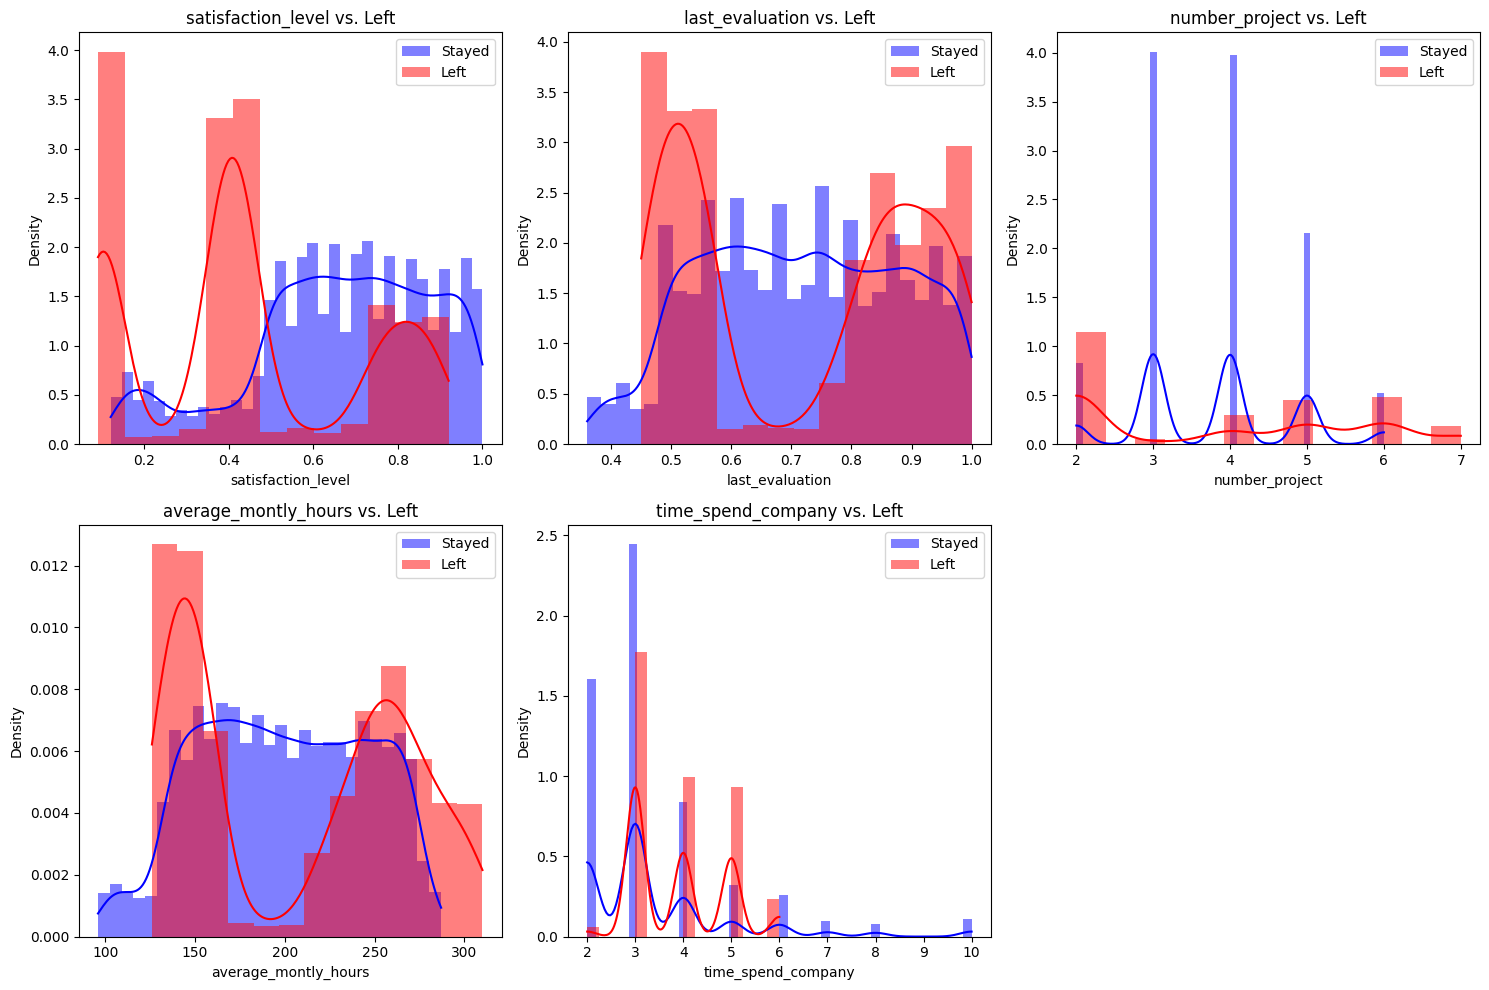

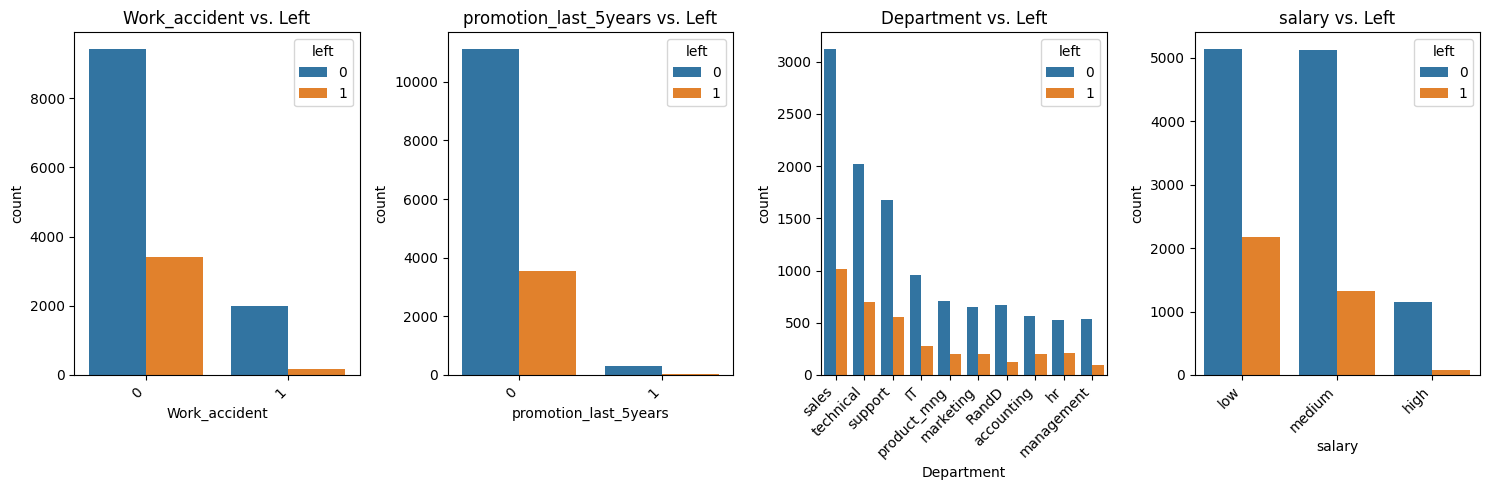


EDA complete. Review the outputs and visualizations to identify variables with clear impact on employee retention.


In [ ]:
import pandas as pd
import io
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data from the content_str variable
df = pd.read_csv(io.StringIO(content_str))

print("Data Head:")
print(df.head())

print("\nData Info:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

# Analyze the 'left' variable (employee retention)
print("\nEmployee Retention (left) distribution:")
print(df['left'].value_counts())
print(df['left'].value_counts(normalize=True) * 100)

# Correlation matrix
print("\nCorrelation Matrix (numerical features with 'left'):")
correlation_matrix = df.corr(numeric_only=True)['left'].sort_values(ascending=False)
print(correlation_matrix)

# Visualizing numerical features vs. 'left'
plt.figure(figsize=(15, 10))
num_cols = ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company']
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[df['left'] == 0][col], color='blue', label='Stayed', kde=True, stat='density', linewidth=0)
    sns.histplot(df[df['left'] == 1][col], color='red', label='Left', kde=True, stat='density', linewidth=0)
    plt.title(f'{col} vs. Left')
    plt.legend()
plt.tight_layout()
plt.show()

# Visualizing categorical features vs. 'left'
plt.figure(figsize=(15, 5))
cat_cols = ['Work_accident', 'promotion_last_5years', 'Department', 'salary']
for i, col in enumerate(cat_cols):
    plt.subplot(1, 4, i + 1)
    if col in ['Work_accident', 'promotion_last_5years']:
        sns.countplot(data=df, x=col, hue='left')
    else:
        sns.countplot(data=df, x=col, hue='left', order=df[col].value_counts().index)
    plt.title(f'{col} vs. Left')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nEDA complete. Review the outputs and visualizations to identify variables with clear impact on employee retention.")